In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
#only shows major errors and ignore the small errors
warnings.filterwarnings('ignore')
print("All libraries imported successfully")
print(f"pandas version: {pd.__version__}")
print(f"sqlite3 version: {sqlite3.version}")

All libraries imported successfully
pandas version: 2.2.2
sqlite3 version: 2.6.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df=pd.read_csv('student_performance.csv')
print(f"Dataset loaded:{df.shape[0]} students,{df.shape[1]} columns")
print(f"Columns:{df.columns.tolist()}")
print("\nFirst 3 rows")
df.head(3)

Dataset loaded:30 students,13 columns
Columns:['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']

First 3 rows


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


In [ ]:
conn=sqlite3.connect('college.db')
#'conn'-connection to the database
#'college.db'-file that will be created in colab filesystem
#if 'college.db' alraedy exists, it opens it else SQL creates it automatically
cursor=conn.cursor()
#cursor is like a pen that writes SQL commands to the database

#write the dataframe to the database
df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False # Do not write DataFrame row numbers as a column
)
# to_sql() automatically
# 1.Creates the table with correct column names and types
# 2.Inserts all the rows from the Dataframe

cursor.execute("SELECT COUNT(*) FROM students")
count=cursor.fetchone()[0]
#fetcthone() retrieves the first result row
#[0] gets the first value from the row (count)

print(f"Database 'college.db' is created successfully")
print(f"Table students has {count} rows")

Database 'college.db' is created successfully
Table students has 30 rows


In [ ]:
#PRAGMA is a special SQLITE command
#table_info shows the structure of the table
cursor.execute("PRAGMA table_info(students)")
columns_info=cursor.fetchall()
#fetchall() retrieves all result rows

print("Table structure of 'students':")
print(f"{'Column Name':<25}{'Data Type':<12}")
print("-"*38)
for col in columns_info:
  print(f"{col[1]:<25} {col[2]:<12}")

Table structure of 'students':
Column Name              Data Type   
--------------------------------------
student_id                INTEGER     
name                      TEXT        
age                       INTEGER     
gender                    TEXT        
department                TEXT        
semester                  INTEGER     
math_score                INTEGER     
science_score             INTEGER     
english_score             INTEGER     
programming_score         INTEGER     
attendance_percentage     INTEGER     
city                      TEXT        
admission_year            INTEGER     


Standard SQL Query pattern

SELECT column1,column2     -Which columns to show

FROM table_name            -Which table to read from

WHERE condition            -Filter rows

GROUP BY column            -Group rows

HAVING group_condition     -Filter groups

ORDER BY column DESC       -Sort results

LIMIT 10                   -Max rows to return






In [ ]:
def run_query(sql, description=""):
  """
  Runs a SQL query and returns result as a Pandas DataFrame

  Parameters:
  -------------
  sql          :str - SQL query string to execute
  description  :str - A label to print above the results

  Returns:
  ----------
   Pandas DataFrame containing the query results
  """
  if description:
    print(f"\n{'='*100}")
    print(f"{description}")
    print(f"{'='*100}")

  result=pd.read_sql_query(sql, conn)
  # 1.Executes the SQL query against the database(conn)
  # 2.Converts the result into Pandas DataFrame
  print(result.to_string(index=False))
  return result

In [ ]:
query1="""
  SELECT student_id,name,department,math_score,attendance_percentage
  FROM students
  LIMIT 10
"""
result=run_query(query1, "Query1: First 10 students (SELECT + LIMIT)")


Query1: First 10 students (SELECT + LIMIT)
 student_id         name       department  math_score  attendance_percentage
       1001 Aarav Sharma Computer Science          85                     92
       1002  Priya Patel Computer Science          76                     87
       1003  Rohit Verma      Electronics          65                     78
       1004  Sneha Reddy       Mechanical          70                     95
       1005   Arjun Nair Computer Science          92                     90
       1006  Meera Joshi      Electronics          58                     72
       1007  Kiran Kumar            Civil          73                     85
       1008  Divya Singh Computer Science          88                     96
       1009 Rahul Mishra       Mechanical          62                     68
       1010   Ananya Das Computer Science          95                     98


In [ ]:
query2="""
  SELECT name,department,math_score
  FROM students
  ORDER BY math_score DESC
  LIMIT 5
"""
result2=run_query(query2,"Query2: Top 5 Math Scorers (ORDER BY DESC + LIMIT)")


Query2: Top 5 Math Scorers (ORDER BY DESC + LIMIT)
          name       department  math_score
    Ananya Das Computer Science          95
   Tanvi Mehta Computer Science          93
    Arjun Nair Computer Science          92
Akanksha Yadav Computer Science          91
Swati Kulkarni Computer Science          90


In [ ]:
query3="""
  SELECT name,math_score,science_score,programming_score,attendance_percentage
  FROM students
  WHERE department='Computer Science'
  ORDER BY programming_score DESC
"""
result3=run_query(query3,"Query3:Computer Science Students (WHERE filter)")
print(f"\nTotal CS students found: {len(result3)}")


Query3:Computer Science Students (WHERE filter)
          name  math_score  science_score  programming_score  attendance_percentage
    Ananya Das          95             89                 97                     98
   Tanvi Mehta          93             90                 96                     97
    Arjun Nair          92             88                 95                     90
Akanksha Yadav          91             93                 94                     95
   Divya Singh          88             91                 93                     96
Swati Kulkarni          90             87                 92                     94
  Aarav Sharma          85             78                 91                     92
     Amit Bose          86             82                 89                     91
    Suresh Rao          83             86                 88                     88
 Gaurav Shukla          84             79                 87                     87
  Nisha Kapoor          79 

In [ ]:
query4="""
  SELECT name,department,attendance_percentage
  FROM students
  WHERE attendance_percentage >50
  AND department != 'Civil'
  ORDER BY attendance_percentage DESC
  """
result4=run_query(query4,"Query4:High Attendance (>50%) Exclusive Civil Department")


Query4:High Attendance (>50%) Exclusive Civil Department
          name       department  attendance_percentage
    Ananya Das Computer Science                     98
   Tanvi Mehta Computer Science                     97
   Divya Singh Computer Science                     96
   Sneha Reddy       Mechanical                     95
Akanksha Yadav Computer Science                     95
Swati Kulkarni Computer Science                     94
  Ritu Agarwal      Electronics                     93
  Aarav Sharma Computer Science                     92
 Kavya Nambiar       Mechanical                     91
     Amit Bose Computer Science                     91
    Arjun Nair Computer Science                     90
  Nisha Kapoor Computer Science                     89
    Suresh Rao Computer Science                     88
   Priya Patel Computer Science                     87
 Gaurav Shukla Computer Science                     87
 Preeti Saxena       Mechanical                     86
    Nit

In [ ]:
query5="""
  SELECT
  department,
  COUNT(*) AS num_students,
  ROUND(AVG(math_score),2) AS avg_math_score,
  ROUND(AVG(science_score),2) AS avg_science_score,
  ROUND(AVG(programming_score),2) AS avg_programming_score,
  ROUND(AVG(attendance_percentage),2) AS avg_attendance_percentage
  FROM students
  GROUP BY department
  ORDER BY avg_math_score DESC
"""
result5=run_query(query5,"Query5:Department Summary")


Query5:Department Summary
      department  num_students  avg_math_score  avg_science_score  avg_programming_score  avg_attendance_percentage
Computer Science            13           85.62              84.46                  89.23                      90.69
      Mechanical             6           71.00              76.50                  49.33                      83.50
     Electronics             6           71.00              74.17                  61.50                      80.33
           Civil             5           63.40              66.60                  40.60                      74.60


In [ ]:
query6="""
    SELECT
    department,
    ROUND(AVG(math_score),2) AS avg_math_score,
    COUNT(*) AS students
    FROM students
    GROUP BY department
    HAVING AVG(math_score)>70
    ORDER BY avg_math_score DESC
"""
result6=run_query(query6,"Query6:Departments with Avg Math Score >70")



Query6:Departments with Avg Math Score >70
      department  avg_math_score  students
Computer Science           85.62        13
      Mechanical           71.00         6
     Electronics           71.00         6


In [ ]:
query7="""
  SELECT
  gender,
  COUNT(*) AS num_students,
  ROUND(AVG(math_score),2) AS avg_math_score,
  ROUND(AVG(programming_score),2) AS avg_programming,
  ROUND(AVG(attendance_percentage),2) AS avg_attendance_percentage
  FROM students
  GROUP BY gender
"""
result7=run_query(query7,"Query7:Gender Based Analysis")


Query7:Gender Based Analysis
gender  num_students  avg_math_score  avg_programming  avg_attendance_percentage
Female            15           78.47             70.2                      88.53
  Male            15           73.67             65.0                      80.47


In [ ]:
query8="""
  SELECT
  name,
  department,
  math_score+science_score+programming_score AS total_score
  FROM students
  ORDER BY total_score DESC
  LIMIT 10
"""
result8=run_query(query8,"Query8:Top 10 Students by Total Score")


Query8:Top 10 Students by Total Score
          name       department  total_score
    Ananya Das Computer Science          281
   Tanvi Mehta Computer Science          279
Akanksha Yadav Computer Science          278
    Arjun Nair Computer Science          275
   Divya Singh Computer Science          272
Swati Kulkarni Computer Science          269
    Suresh Rao Computer Science          257
     Amit Bose Computer Science          257
  Aarav Sharma Computer Science          254
 Gaurav Shukla Computer Science          250


In [ ]:
dept_data={
    'dept_code':['CS','EC','ME','CE'],
    'dept_name':['Computer Science','Electronics','Mechanical','Civil'],
    'hod_name':['Dr.Sudha','Dr Arjun','Dr Mathi','Dr Krish'],
    'established':[1985,1988,1972,1965],
    'intake':[60,60,60,60]
}
dept_df=pd.DataFrame(dept_data)
dept_df.to_sql('departments',conn,if_exists='replace',index=False)
print("Created 'departments' table:")
print(dept_df.to_string(index=False))
dept_map={
    'Computer Science':'CS',
    'Electronics':'EC',
    'Mechanical':'ME',
    'Civil':'CE'
}
df['dept_code']=df['department'].map(dept_map)
df.to_sql('students',conn,if_exists='replace',index=False)

Created 'departments' table:
dept_code        dept_name hod_name  established  intake
       CS Computer Science Dr.Sudha         1985      60
       EC      Electronics Dr Arjun         1988      60
       ME       Mechanical Dr Mathi         1972      60
       CE            Civil Dr Krish         1965      60


30

In [ ]:
query_join="""
SELECT
  s.name,
  s.math_score,
  d.dept_name,
  d.hod_name,
  d.established
FROM students AS s
INNER JOIN departments AS d
  ON s.dept_code=d.dept_code
ORDER BY s.math_score DESC
LIMIT 8
"""
result_join = run_query(query_join, "Query Join: Students with Department Details")


Query Join: Students with Department Details
          name  math_score        dept_name hod_name  established
    Ananya Das          95 Computer Science Dr.Sudha         1985
   Tanvi Mehta          93 Computer Science Dr.Sudha         1985
    Arjun Nair          92 Computer Science Dr.Sudha         1985
Akanksha Yadav          91 Computer Science Dr.Sudha         1985
Swati Kulkarni          90 Computer Science Dr.Sudha         1985
   Divya Singh          88 Computer Science Dr.Sudha         1985
  Ritu Agarwal          87      Electronics Dr Arjun         1988
     Amit Bose          86 Computer Science Dr.Sudha         1985


# UNIT 3: Data Visualization with Matplotlib

Now we turn our SQL results into professional charts.

## The Pattern we follow:

SQL Query → `pd.read_sql_query()` → DataFrame → Matplotlib chart

---

## Matplotlib Anatomy

```python
fig, ax = plt.subplots(figsize=(width, height))

ax.bar(x, y)

ax.set_title('...')

ax.set_xlabel('...')

ax.set_ylabel('...')

plt.tight_layout()

plt.show()

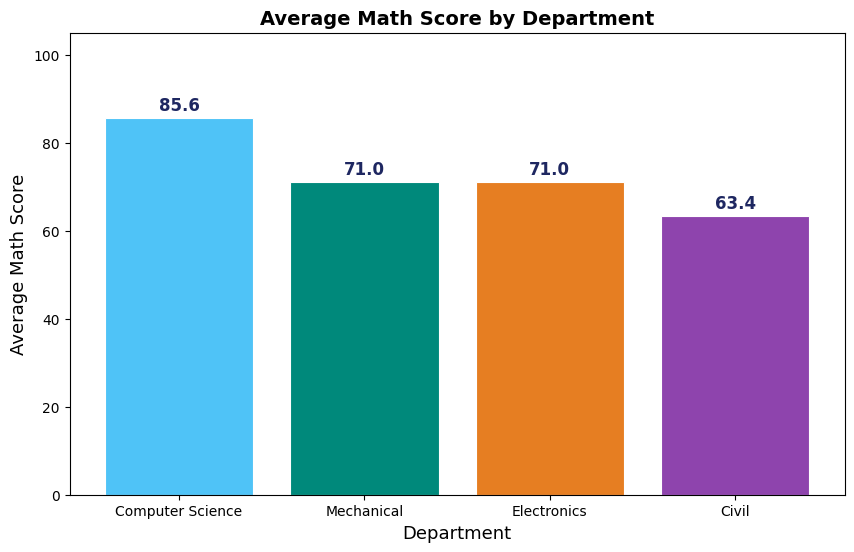

In [ ]:
# Step 1: Get data using SQL

chart1_sql = """
SELECT department, ROUND (AVG(math_score), 2) AS avg_math
FROM students
GROUP BY department
ORDER BY avg_math DESC
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)
# pd.read sql query runs the SQL and returns a DataFrame
# chart1_data has two columns: 'department' and 'avg_math'

# Step 2: Create the bar chart
fig, ax = plt.subplots(figsize=(10, 6))
# fig = the whole figure (canvas)
# ax = the axes object (the actual plot area)
# figsize=(10, 6) = 10 inches wide, 6 inches tall

bar_colors = ['#4FC3F7', '#00897B', '#E67E22', '#8E44AD']
# List of hex color codes - one color per department bar

bars = ax.bar(
  chart1_data['department'], # x-axis values (category labels)
  chart1_data['avg_math'], #y-axis values (heights of bars)
  color=bar_colors, #colors for each bar
  edgecolor='white', #white border aroun
  linewidth=0.8 #thickness of the border
)
#ax.bar() draws one bar per x-value, with height = y-value
# Add value labels ON TOP of each bar

for bar in bars:
# Loop through each bar object
  height = bar.get_height()
# .get_height() returns the bar's height (= the avg_math value)
  ax.text(
  # x position: center of bar
  # y position: just above bar top
  # text: height formatted to 1 decimal
  bar.get_x() + bar.get_width() / 2,
  height + 0.8,
  f'{height:.1f}',
  ha='center', va='bottom', fontsize=12, fontweight='bold', color='#1E2761'
  )
# horizontal/vertical alignment

ax.set_title('Average Math Score by Department', fontsize=14, fontweight='bold') # Corrected: Removed 'Dad' and added closing parenthesis
ax.set_xlabel('Department', fontsize=13)
ax.set_ylabel('Average Math Score', fontsize=13)
ax.set_ylim(0, 105) # y-axis from 0 to 105 so labels
plt.show()

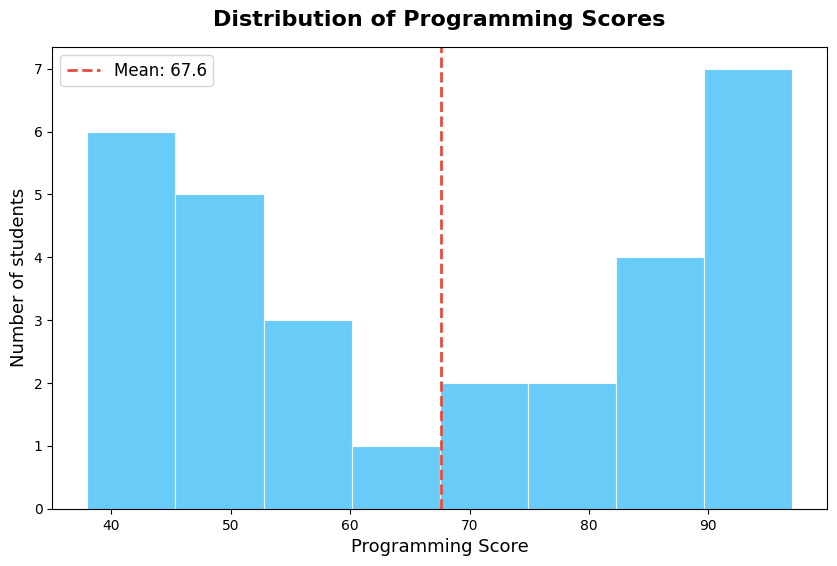

In [ ]:
prog_scores=df['programming_score'].tolist()
fig,ax=plt.subplots(figsize=(10,6))
n,bins,patches=ax.hist(
    prog_scores,
    bins=8,
    color='#4FC3F7',
    edgecolor='white',
    linewidth=0.8,
    alpha=0.85
)
mean_score=sum(prog_scores)/len(prog_scores)
ax.axvline(
    x=mean_score,
    color='#E74C3C',
    linestyle='--',
    linewidth=2,
    label=f'Mean: {mean_score:.1f}'
)
ax.set_title('Distribution of Programming Scores',fontsize=16,fontweight='bold',pad=15)
ax.set_xlabel('Programming Score',fontsize=13)
ax.set_ylabel('Number of students',fontsize=13)
ax.legend(fontsize=12)
plt.show()

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

df = pd.DataFrame({
'Category': np.random.choice(['A','B','C','D'], 100),
'Value': np.random.randint(10, 100, 100),
'Score': np.random.randint(1, 10, 100)
})
df.head()

,Category,Value,Score
0,C,51,4
1,B,25,4
2,B,14,2
3,B,50,2
4,C,81,5


In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

category_counts=df['Category'].value_counts().reset_index()
category_counts.columns=['Category','Count']
fig=px.bar(
    category_counts,
    x='Category',
    y='Count',
    color='Category',
    title='Interactive Category Distribution',
    text='Count'
)

fig.update_traces(textposition='outside')
fig.update_layout(xaxis_title="Category", yaxis_title="Count", width=600, height=400)
fig.show()